Comparison of Different Regression Algorithms for Predictive Modeling
Machine Learning Laboratory

Aim:-
To compare the performance of different regression algorithms on a given dataset and identify the most suitable algorithm for accurate prediction.

Objectives:-
To understand the working principles of various regression algorithms.
To apply multiple regression models to the same dataset.
To evaluate model performance using suitable error metrics.
To determine which algorithm best fits the given problem based on accuracy and efficiency.
Relevance
Regression analysis is an important supervised learning technique used to predict continuous numerical outcomes. It is widely used in applications such as house price prediction, sales forecasting, temperature prediction and demand estimation.

In this experiment, different regression algorithms are applied to the same dataset and their performances are compared using error metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE) and R² Score.

Comparing multiple algorithms helps in selecting the most suitable model according to the characteristics of the dataset, such as linearity, non-linearity, noise and feature relationships.

In [10]:
# Import libraries required for data analysis, preprocessing, modeling and evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import time

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [11]:
# Load the California Housing dataset from scikit-learn

data = fetch_california_housing()

print("California Housing dataset loaded successfully.")

California Housing dataset loaded successfully.


In [12]:
# Convert the feature data into a pandas DataFrame

X = pd.DataFrame(data.data, columns=data.feature_names)

y = pd.Series(
    data.target,
    name="House_Value"
)

print("Features and target variable created successfully.")

Features and target variable created successfully.


In [13]:
# Display the first five records of the dataset

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
# Display the number of observations and features

print("Number of observations:", X.shape[0])
print("Number of features:", X.shape[1])
print("Total dataset shape:", X.shape)

Number of observations: 20640
Number of features: 8
Total dataset shape: (20640, 8)


In [15]:
# Display the feature names and their data types

print("Feature Names:")
for feature in X.columns:
    print("-", feature)

print("\nData Types:")
print(X.dtypes)

Feature Names:
- MedInc
- HouseAge
- AveRooms
- AveBedrms
- Population
- AveOccup
- Latitude
- Longitude

Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object


In [16]:
# Generate descriptive statistics for all numerical features

X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [17]:
# Check for missing values in the feature dataset

missing_values = X.isnull().sum()

print("Missing values in each feature:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each feature:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Total missing values: 0


In [18]:
# Analyze the target variable used for house-value prediction

print("Target Variable: House_Value")
print("Minimum value:", y.min())
print("Maximum value:", y.max())
print("Mean value:", y.mean())
print("Median value:", y.median())

Target Variable: House_Value
Minimum value: 0.14999
Maximum value: 5.00001
Mean value: 2.0685581690891475
Median value: 1.797


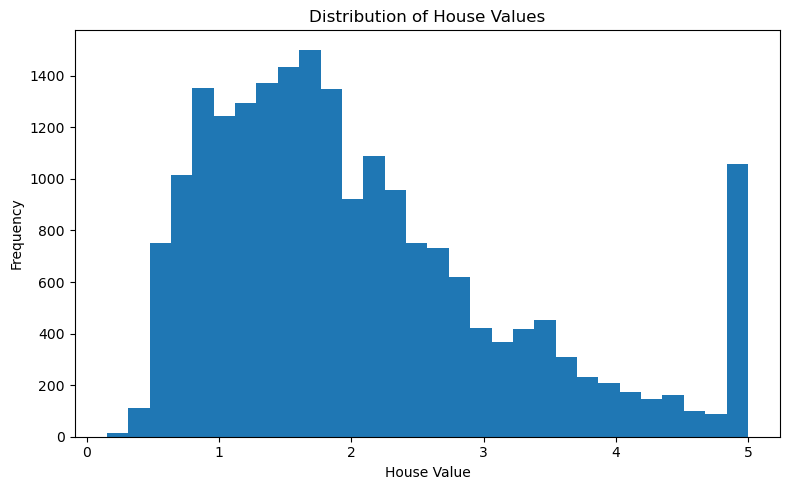

In [19]:
# Visualize the distribution of the target variable

plt.figure(figsize=(8, 5))

plt.hist(y, bins=30)

plt.xlabel("House Value")
plt.ylabel("Frequency")
plt.title("Distribution of House Values")

plt.tight_layout()
plt.show()

In [20]:
# Calculate the correlation of each feature with the target variable

correlation_data = X.copy()
correlation_data["House_Value"] = y

target_correlation = correlation_data.corr()["House_Value"].sort_values(
    ascending=False
)

print("Correlation of features with House Value:")
print(target_correlation)

Correlation of features with House Value:
House_Value    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: House_Value, dtype: float64


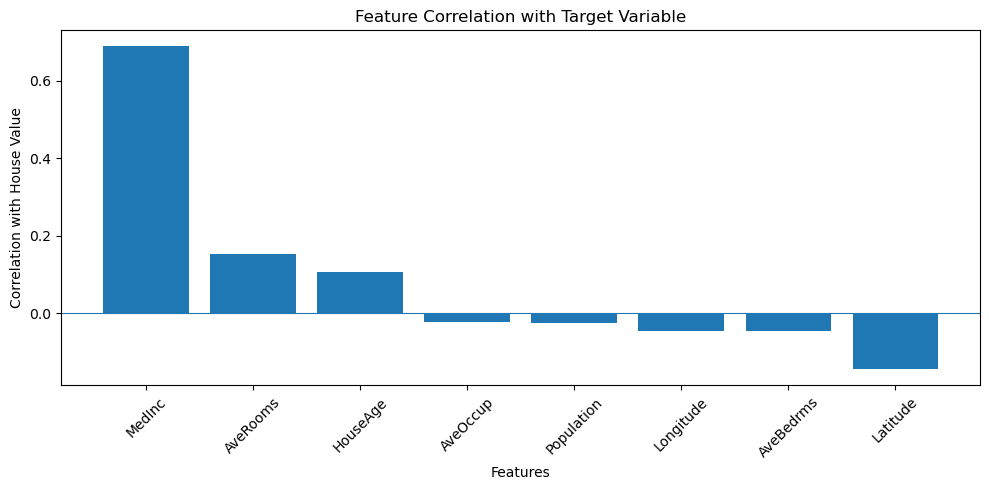

In [21]:
# Visualize the relationship between features and the target variable

feature_correlations = target_correlation.drop("House_Value")

plt.figure(figsize=(10, 5))

plt.bar(
    feature_correlations.index,
    feature_correlations.values
)

plt.xlabel("Features")
plt.ylabel("Correlation with House Value")
plt.title("Feature Correlation with Target Variable")

plt.xticks(rotation=45)
plt.axhline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [22]:
# Separate input features and target variable

X = X.copy()
y = y.copy()

print("Input features shape:", X.shape)
print("Target variable shape:", y.shape)

Input features shape: (20640, 8)
Target variable shape: (20640,)


In [23]:
# Split the dataset into training and testing subsets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (16512, 8)
Testing set size: (4128, 8)


In [24]:
# Standardize features so that they have comparable scales

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [25]:
# Create the Linear Regression model

linear_model = LinearRegression()

print("Linear Regression model created.")

Linear Regression model created.


In [26]:
# Train the Linear Regression model and measure training time

start_time = time.time()

linear_model.fit(X_train, y_train)

linear_training_time = time.time() - start_time

print("Linear Regression training completed.")
print("Training time:", round(linear_training_time, 4), "seconds")

Linear Regression training completed.
Training time: 0.0202 seconds


In [27]:
# Generate predictions using the Linear Regression model

linear_pred = linear_model.predict(X_test)

print("Linear Regression predictions generated.")
print("First 10 predictions:")
print(linear_pred[:10])

Linear Regression predictions generated.
First 10 predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [28]:
# Generate second-degree polynomial features

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Polynomial features created successfully.")
print("Original number of features:", X_train.shape[1])
print("Polynomial feature shape:", X_train_poly.shape)

Polynomial features created successfully.
Original number of features: 8
Polynomial feature shape: (16512, 45)


In [29]:
# Train the Polynomial Regression model

polynomial_model = LinearRegression()

start_time = time.time()

polynomial_model.fit(X_train_poly, y_train)

polynomial_training_time = time.time() - start_time

print("Polynomial Regression training completed.")
print("Training time:", round(polynomial_training_time, 4), "seconds")

Polynomial Regression training completed.
Training time: 0.1165 seconds


In [30]:
# Generate predictions using Polynomial Regression

polynomial_pred = polynomial_model.predict(X_test_poly)

print("Polynomial Regression predictions generated.")
print("First 10 predictions:")
print(polynomial_pred[:10])

Polynomial Regression predictions generated.
First 10 predictions:
[0.55399741 1.75118566 3.49237927 2.84966861 2.76242555 1.91347095
 2.66475779 2.01544906 2.8938098  3.96746576]


In [31]:
# Create the Decision Tree Regression model

decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

print("Decision Tree Regression model created.")

Decision Tree Regression model created.


In [32]:
# Train the Decision Tree Regression model

start_time = time.time()

decision_tree_model.fit(X_train, y_train)

decision_tree_training_time = time.time() - start_time

print("Decision Tree Regression training completed.")
print("Training time:", round(decision_tree_training_time, 4), "seconds")

Decision Tree Regression training completed.
Training time: 0.7676 seconds


In [33]:
# Generate predictions using the Decision Tree model

decision_tree_pred = decision_tree_model.predict(X_test)

print("Decision Tree predictions generated.")
print("First 10 predictions:")
print(decision_tree_pred[:10])

Decision Tree predictions generated.
First 10 predictions:
[0.414   1.203   5.00001 2.17    2.257   1.787   2.217   1.74    2.772
 5.00001]


In [34]:
# Create the Random Forest Regression model

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Regression model created.")

Random Forest Regression model created.


In [35]:
# Train the Random Forest Regression model

start_time = time.time()

random_forest_model.fit(X_train, y_train)

random_forest_training_time = time.time() - start_time

print("Random Forest Regression training completed.")
print("Training time:", round(random_forest_training_time, 4), "seconds")

Random Forest Regression training completed.
Training time: 6.9527 seconds


In [36]:
# Generate predictions using the Random Forest model

random_forest_pred = random_forest_model.predict(X_test)

print("Random Forest predictions generated.")
print("First 10 predictions:")
print(random_forest_pred[:10])

Random Forest predictions generated.
First 10 predictions:
[0.5095    0.74161   4.9232571 2.52961   2.27369   1.64692   2.37605
 1.66932   2.7729706 4.9134589]


In [37]:
# Create the Support Vector Regression model

svr_model = SVR(
    kernel="rbf"
)

print("Support Vector Regression model created.")

Support Vector Regression model created.


In [38]:
# Train the Support Vector Regression model

start_time = time.time()

svr_model.fit(X_train_scaled, y_train)

svr_training_time = time.time() - start_time

print("Support Vector Regression training completed.")
print("Training time:", round(svr_training_time, 4), "seconds")

Support Vector Regression training completed.
Training time: 29.4439 seconds


In [39]:
# Generate predictions using the SVR model

svr_pred = svr_model.predict(X_test_scaled)

print("SVR predictions generated.")
print("First 10 predictions:")
print(svr_pred[:10])

SVR predictions generated.
First 10 predictions:
[0.51647228 1.56842925 3.59780295 2.49108208 2.56880838 1.67166034
 2.62538359 1.72918458 2.31909544 4.73053473]


MODEL EVALUATION

In [40]:
# Define a function to calculate regression performance metrics

def evaluate_model(y_actual, y_predicted):
    
    mae = mean_absolute_error(y_actual, y_predicted)
    mse = mean_squared_error(y_actual, y_predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual, y_predicted)
    
    return mae, mse, rmse, r2

In [41]:
# Calculate evaluation metrics for all regression models

linear_mae, linear_mse, linear_rmse, linear_r2 = evaluate_model(
    y_test, linear_pred
)

polynomial_mae, polynomial_mse, polynomial_rmse, polynomial_r2 = evaluate_model(
    y_test, polynomial_pred
)

decision_tree_mae, decision_tree_mse, decision_tree_rmse, decision_tree_r2 = evaluate_model(
    y_test, decision_tree_pred
)

random_forest_mae, random_forest_mse, random_forest_rmse, random_forest_r2 = evaluate_model(
    y_test, random_forest_pred
)

svr_mae, svr_mse, svr_rmse, svr_r2 = evaluate_model(
    y_test, svr_pred
)

print("All models evaluated successfully.")

All models evaluated successfully.


In [42]:
# Create a DataFrame containing the performance of all models

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree Regression",
        "Random Forest Regression",
        "Support Vector Regression"
    ],
    
    "MAE": [
        linear_mae,
        polynomial_mae,
        decision_tree_mae,
        random_forest_mae,
        svr_mae
    ],
    
    "MSE": [
        linear_mse,
        polynomial_mse,
        decision_tree_mse,
        random_forest_mse,
        svr_mse
    ],
    
    "RMSE": [
        linear_rmse,
        polynomial_rmse,
        decision_tree_rmse,
        random_forest_rmse,
        svr_rmse
    ],
    
    "R2 Score": [
        linear_r2,
        polynomial_r2,
        decision_tree_r2,
        random_forest_r2,
        svr_r2
    ],
    
    "Training Time (sec)": [
        linear_training_time,
        polynomial_training_time,
        decision_tree_training_time,
        random_forest_training_time,
        svr_training_time
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score,Training Time (sec)
0,Linear Regression,0.533200,0.555892,0.745581,0.575788,0.020222
1,Polynomial Regression,0.467001,0.464302,0.681397,0.645682,0.116486
2,Decision Tree Regression,0.454679,0.495235,0.703729,0.622076,0.767562
3,Random Forest Regression,0.327543,0.255368,0.505340,0.805123,6.952717
4,Support Vector Regression,0.398599,0.357004,0.597498,0.727563,29.443919


In [43]:
# Round numerical values for a cleaner comparison table

results_display = results.copy()

numeric_columns = [
    "MAE",
    "MSE",
    "RMSE",
    "R2 Score",
    "Training Time (sec)"
]

results_display[numeric_columns] = results_display[numeric_columns].round(4)

results_display

,Model,MAE,MSE,RMSE,R2 Score,Training Time (sec)
0,Linear Regression,0.5332,0.5559,0.7456,0.5758,0.0202
1,Polynomial Regression,0.4670,0.4643,0.6814,0.6457,0.1165
2,Decision Tree Regression,0.4547,0.4952,0.7037,0.6221,0.7676
3,Random Forest Regression,0.3275,0.2554,0.5053,0.8051,6.9527
4,Support Vector Regression,0.3986,0.3570,0.5975,0.7276,29.4439


In [44]:
# Rank the models according to their R2 score

r2_ranking = results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

r2_ranking["Rank"] = range(1, len(r2_ranking) + 1)

r2_ranking

,Model,MAE,MSE,RMSE,R2 Score,Training Time (sec),Rank
0,Random Forest Regression,0.327543,0.255368,0.505340,0.805123,6.952717,1
1,Support Vector Regression,0.398599,0.357004,0.597498,0.727563,29.443919,2
2,Polynomial Regression,0.467001,0.464302,0.681397,0.645682,0.116486,3
3,Decision Tree Regression,0.454679,0.495235,0.703729,0.622076,0.767562,4
4,Linear Regression,0.533200,0.555892,0.745581,0.575788,0.020222,5


In [45]:
# Identify the best-performing model based on the highest R2 score

best_model_row = results.loc[
    results["R2 Score"].idxmax()
]

print("Best Regression Model:", best_model_row["Model"])
print("R2 Score:", round(best_model_row["R2 Score"], 4))
print("RMSE:", round(best_model_row["RMSE"], 4))
print("MAE:", round(best_model_row["MAE"], 4))

Best Regression Model: Random Forest Regression
R2 Score: 0.8051
RMSE: 0.5053
MAE: 0.3275


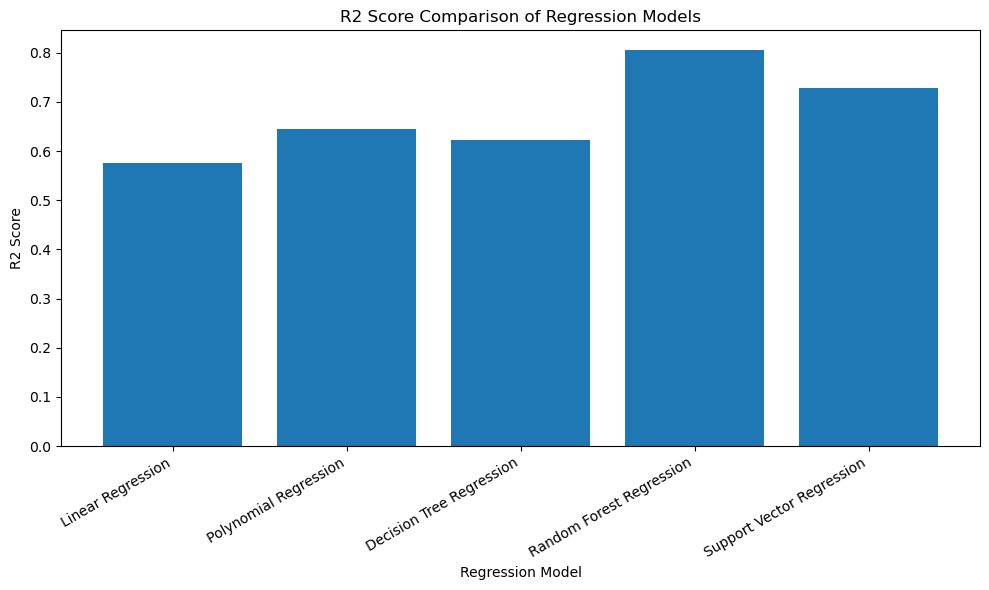

In [46]:
# Compare the R2 scores of all regression models

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.xlabel("Regression Model")
plt.ylabel("R2 Score")
plt.title("R2 Score Comparison of Regression Models")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

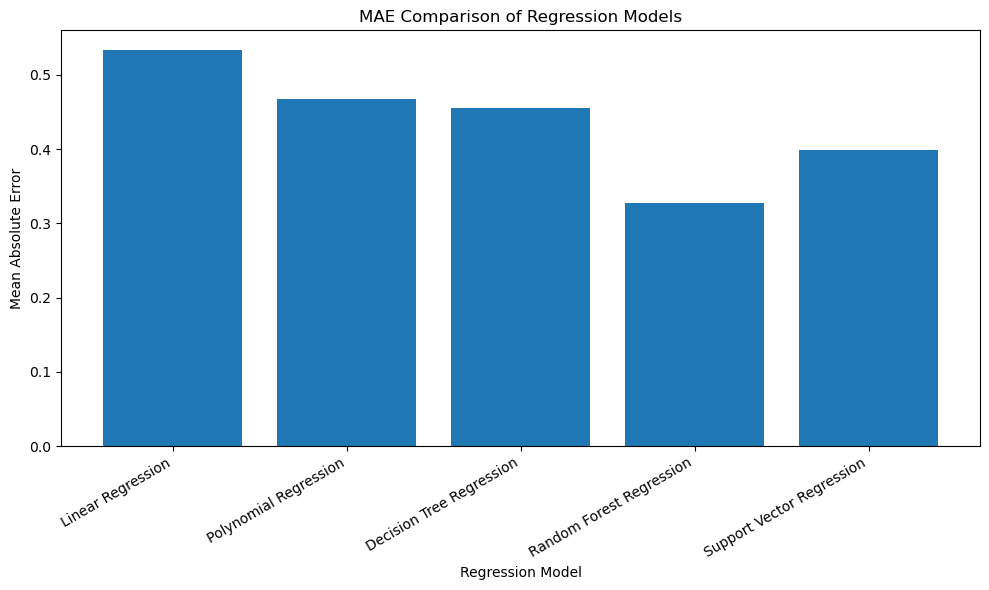

In [47]:
# Compare Mean Absolute Error of all regression models

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.xlabel("Regression Model")
plt.ylabel("Mean Absolute Error")
plt.title("MAE Comparison of Regression Models")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

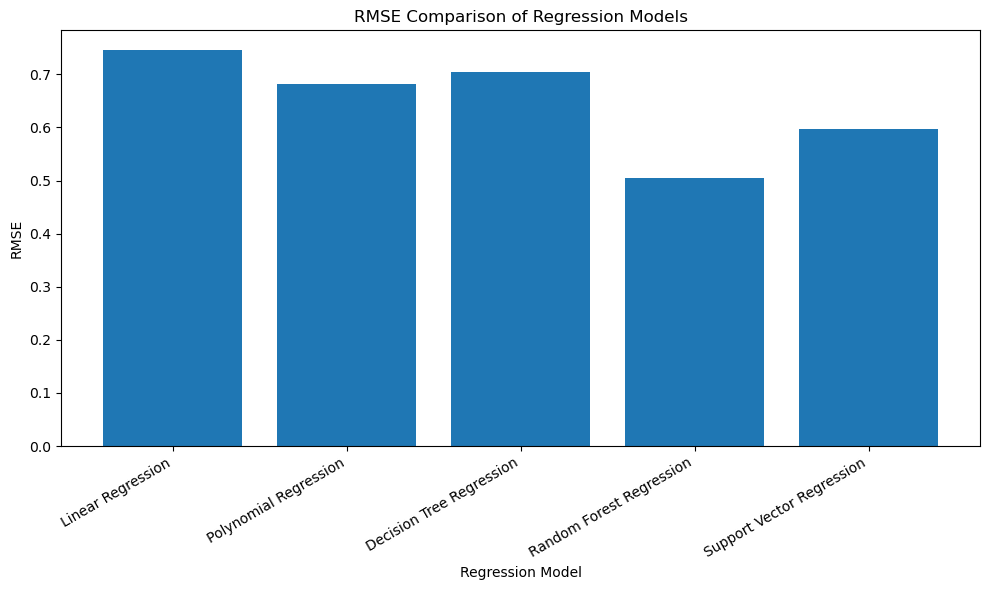

In [48]:
# Compare Root Mean Squared Error of all regression models

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Regression Models")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

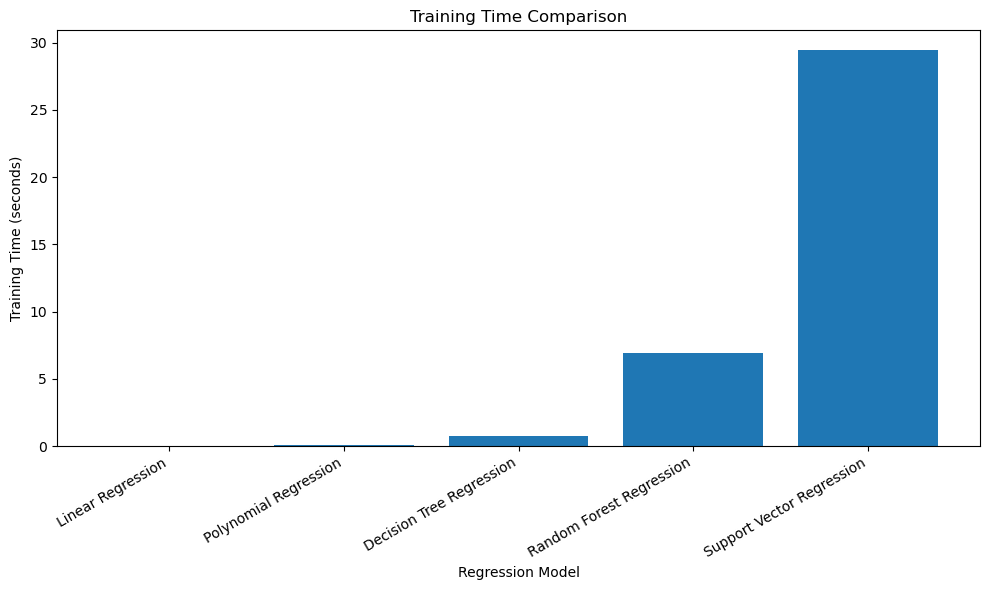

In [49]:
# Compare the training time of all regression models

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["Training Time (sec)"]
)

plt.xlabel("Regression Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Actual vs Predicted Values

In [50]:
# Select predictions corresponding to the best-performing model

best_model_name = best_model_row["Model"]

if best_model_name == "Linear Regression":
    best_predictions = linear_pred

elif best_model_name == "Polynomial Regression":
    best_predictions = polynomial_pred

elif best_model_name == "Decision Tree Regression":
    best_predictions = decision_tree_pred

elif best_model_name == "Random Forest Regression":
    best_predictions = random_forest_pred

else:
    best_predictions = svr_pred

print("Selected Best Model:", best_model_name)

Selected Best Model: Random Forest Regression


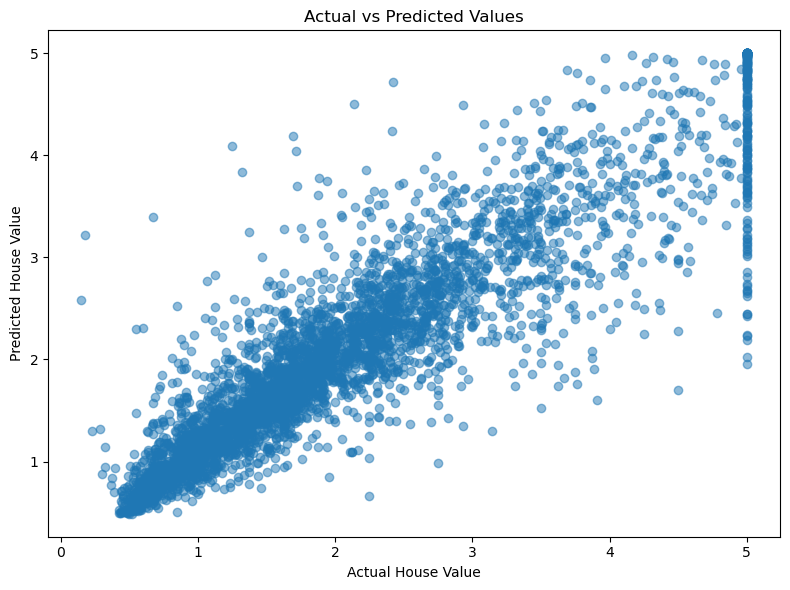

In [51]:
# Compare actual and predicted values for the best-performing model

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")

plt.tight_layout()
plt.show()

In [52]:
# Display a sample comparison of actual and predicted values

comparison = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": best_predictions
})

comparison["Absolute Error"] = abs(
    comparison["Actual Value"] - comparison["Predicted Value"]
)

comparison.head(10)

,Actual Value,Predicted Value,Absolute Error
0,0.47700,0.509500,0.032500
1,0.45800,0.741610,0.283610
2,5.00001,4.923257,0.076753
3,2.18600,2.529610,0.343610
4,2.78000,2.273690,0.506310
5,1.58700,1.646920,0.059920
6,1.98200,2.376050,0.394050
7,1.57500,1.669320,0.094320
8,3.40000,2.772971,0.627029
9,4.46600,4.913459,0.447459


In [53]:
# Display the final result of the regression model comparison

print("=" * 60)
print("FINAL REGRESSION MODEL COMPARISON RESULT")
print("=" * 60)

print("\nBest Performing Model :", best_model_row["Model"])
print("R2 Score              :", round(best_model_row["R2 Score"], 4))
print("RMSE                  :", round(best_model_row["RMSE"], 4))
print("MAE                   :", round(best_model_row["MAE"], 4))
print("Training Time         :", round(best_model_row["Training Time (sec)"], 4), "seconds")

print("\nHigher R2 Score indicates better model fit.")
print("Lower MAE and RMSE indicate lower prediction error.")

FINAL REGRESSION MODEL COMPARISON RESULT

Best Performing Model : Random Forest Regression
R2 Score              : 0.8051
RMSE                  : 0.5053
MAE                   : 0.3275
Training Time         : 6.9527 seconds

Higher R2 Score indicates better model fit.
Lower MAE and RMSE indicate lower prediction error.


Conclude